# Review behavior: movies, users, and popularity

This notebook examines **user–movie interactions** in **Movies_and_TV.csv** (same schema as [DatasetDescription.md](../DatasetDescription.md): `item_id`, `user_id`, `rating`, `timestamp`). It focuses on factors that influence **how a movie is reviewed** and **how users review**.

**Questions addressed**

1. Correlation between **how many reviews a movie has** (full dataset) and its **average rating**.
2. Correlation between **movie review count** and **divisiveness** (standard deviation of ratings).
3. Correlation between **how many reviews a user gives** and their **average score** (a proxy for “harshness”).
4. **Heavy users**: compare review behaviour (means, spread, star mix) to lighter users.

**Note:** We load **all rows** from **Movies_and_TV.csv** using chunked reads concatenated into one DataFrame (**no random subsampling**). **`n_reviews`** for each movie/user counts **every matching row** in this file. **`MIN_MOVIE_REVIEWS`** / **`MIN_USER_REVIEWS`** exclude very sparse entities so means and SDs are stable. Full-data analysis uses substantial **RAM** and may take noticeably longer than a subsample.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def _corr_strength_label(r: float) -> str:
    """Rough |r| bands for reporting (exploratory only)."""
    a = abs(float(r))
    if a < 0.10:
        return "negligible"
    if a < 0.30:
        return "weak"
    if a < 0.50:
        return "moderate"
    return "strong"


def correlation_report(x, y, title: str):
    """Pearson (raw n), Pearson on log1p(n) to match log-x plots, Spearman, Kendall τ."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    pr, pp = stats.pearsonr(x, y)
    pr_log, pp_log = stats.pearsonr(np.log1p(x), y)
    sr, sp = stats.spearmanr(x, y)
    kt, kp = stats.kendalltau(x, y)
    return {
        "relationship": title,
        "n_points": int(len(x)),
        "pearson_r_raw_n": float(pr),
        "p_pearson_raw": float(pp),
        "pearson_r_log1p_n": float(pr_log),
        "p_pearson_log1p": float(pp_log),
        "r_squared_log1p_pearson": float(pr_log) ** 2,
        "spearman_rho": float(sr),
        "p_spearman": float(sp),
        "kendall_tau": float(kt),
        "p_kendall": float(kp),
        "strength_raw_pearson": _corr_strength_label(pr),
        "strength_spearman": _corr_strength_label(sr),
    }


def dichotomous_correlation_report(x_binary, y, title: str):
    """Pearson r between a 0/1 indicator and a continuous outcome equals the point-biserial correlation."""
    x = np.asarray(x_binary, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    pr, pp = stats.pearsonr(x, y)
    sr, sp = stats.spearmanr(x, y)
    kt, kp = stats.kendalltau(x, y)
    return {
        "relationship": title,
        "n_points": int(len(x)),
        "pearson_r_raw_n": float(pr),
        "p_pearson_raw": float(pp),
        "pearson_r_log1p_n": np.nan,
        "p_pearson_log1p": np.nan,
        "r_squared_log1p_pearson": np.nan,
        "spearman_rho": float(sr),
        "p_spearman": float(sp),
        "kendall_tau": float(kt),
        "p_kendall": float(kp),
        "strength_raw_pearson": _corr_strength_label(pr),
        "strength_spearman": _corr_strength_label(sr),
    }

## 1. Load full dataset

Read the CSV in chunks of `CHUNK_ROWS` rows and concatenate to one table. Tune `CHUNK_ROWS` if you need to reduce peak memory during the read.


In [2]:
CSV_PATH = "Movies_and_TV.csv"
COLS = ["item_id", "user_id", "rating", "timestamp"]
CHUNK_ROWS = 500_000

parts = []
for chunk in pd.read_csv(
    CSV_PATH,
    header=None,
    names=COLS,
    chunksize=CHUNK_ROWS,
):
    parts.append(chunk)

df = pd.concat(parts, ignore_index=True)
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)

print(f"Loaded rows: {len(df):,}")
df.head()


Loaded rows: 8,765,568


,item_id,user_id,rating,timestamp,datetime
0,0001527665,A3478QRKQDOPQ2,5.0,1362960000,2013-03-11 00:00:00+00:00
1,0001527665,A2VHSG6TZHU1OB,5.0,1361145600,2013-02-18 00:00:00+00:00
2,0001527665,A23EJWOW1TLENE,5.0,1358380800,2013-01-17 00:00:00+00:00
3,0001527665,A1KM9FNEJ8Q171,5.0,1357776000,2013-01-10 00:00:00+00:00
4,0001527665,A38LY2SSHVHRYB,4.0,1356480000,2012-12-26 00:00:00+00:00


## 2. Movie-level and user-level aggregates

We aggregate ratings **by movie** (`item_id`) and **by user** (`user_id`).

- **`n_reviews`**: number of review rows in the **full loaded dataset** for that movie or user.
- **`mean_rating`**: average star rating (1–5).
- **`std_rating`**: sample standard deviation of ratings (divisiveness); defined only if there are at least two ratings.

**Filters** (tune as needed):

- `MIN_MOVIE_REVIEWS`: drop movies with fewer than this many reviews **in the file** before correlating count vs mean/std.
- `MIN_USER_REVIEWS`: same for user-level “harshness” analysis.

**About filtered *n*:** With the **full** extract, counts reflect total activity in **Movies_and_TV.csv**. The minimum-review filters still remove users or titles with fewer than the threshold reviews so per-entity means and SDs are not driven by noise; filtered row counts are typically **much larger** than in a random subsample.


In [3]:
MIN_MOVIE_REVIEWS = 5
MIN_USER_REVIEWS = 5

movie_stats = (
    df.groupby("item_id", sort=False)
    .agg(n_reviews=("rating", "size"), mean_rating=("rating", "mean"), std_rating=("rating", "std"))
    .reset_index()
)
movie_stats["std_rating"] = movie_stats["std_rating"].fillna(np.nan)

user_stats = (
    df.groupby("user_id", sort=False)
    .agg(n_reviews=("rating", "size"), mean_rating=("rating", "mean"), std_rating=("rating", "std"))
    .reset_index()
)

movies_f = movie_stats[movie_stats["n_reviews"] >= MIN_MOVIE_REVIEWS].copy()
movies_f_std = movies_f[movies_f["n_reviews"] >= 2].dropna(subset=["std_rating"])

users_f = user_stats[user_stats["n_reviews"] >= MIN_USER_REVIEWS].copy()

print(
    f"Movies in dataset: {len(movie_stats):,}; after n≥{MIN_MOVIE_REVIEWS}: {len(movies_f):,}"
)
print(
    f"Users in dataset: {len(user_stats):,}; after n≥{MIN_USER_REVIEWS}: {len(users_f):,}"
)
display(movies_f.head())
display(users_f.head())

# Filled in sections 3–5 with one row per scatter plot
CORR_RESULTS = []


Movies in dataset: 182,032; after n≥5: 89,590
Users in dataset: 3,826,085; after n≥5: 311,221


,item_id,n_reviews,mean_rating,std_rating
0,0001527665,18,4.166667,1.504894
1,0005089549,17,4.823529,0.727607
2,000503860X,27,4.814815,0.483341
3,0005419263,48,4.791667,0.617419
4,0005092663,50,4.400000,1.160577


,user_id,n_reviews,mean_rating,std_rating
0,A3478QRKQDOPQ2,48,3.479167,1.110675
9,A2M1CU2IRZG0K9,7,4.285714,0.755929
11,AFTUJYISOFHY6,5,5.000000,0.000000
21,A3JVF9Y53BEOGC,31,3.806452,1.470133
22,A12VPEOEZS1KTC,42,4.166667,1.057301


## 3. Movie popularity vs average rating

**Question:** Is there a correlation between the number of reviews a movie has and the average review score?

We report **Pearson** on raw counts and on **log1p(n)** (aligned with the log-scaled *x*-axis), **Spearman ρ**, and **Kendall τ**, plus **R²** from the log-scale Pearson. A combined **summary table** appears after all three figures. The **|ρ| strength** label maps |Spearman ρ| to **negligible / weak / moderate / strong** (exploratory bands, same as the printout).

Movie review count vs mean rating — correlation strength
  n movies: 89,590
  Pearson r (raw count vs mean):     +0.0403  (p=1.88e-33)  [negligible]
  Pearson r (log1p count vs mean):   +0.0981  (p=2.39e-190)  matches log-x axis; R²=0.0096
  Spearman rho (rank):             +0.0672  (p=2.74e-90)  [negligible]
  Kendall tau:                     +0.0471  (p=3.10e-96)


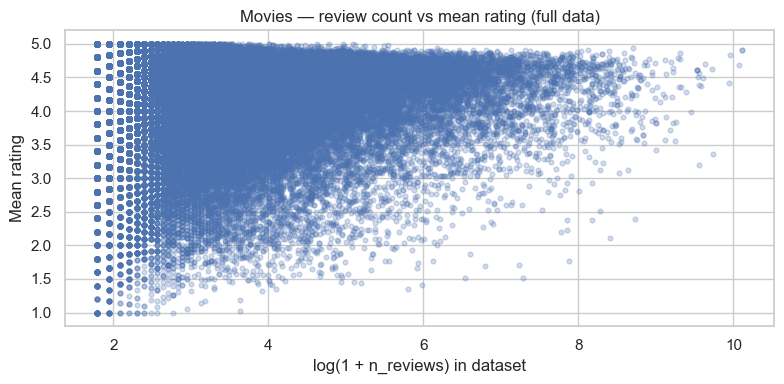

In [4]:
x = movies_f["n_reviews"]
y = movies_f["mean_rating"]

rep = correlation_report(x, y, "Movie: n_reviews vs mean_rating")
CORR_RESULTS.append(rep)

print("Movie review count vs mean rating — correlation strength")
print(f"  n movies: {rep['n_points']:,}")
print(f"  Pearson r (raw count vs mean):     {rep['pearson_r_raw_n']:+.4f}  (p={rep['p_pearson_raw']:.2e})  [{rep['strength_raw_pearson']}]")
print(f"  Pearson r (log1p count vs mean):   {rep['pearson_r_log1p_n']:+.4f}  (p={rep['p_pearson_log1p']:.2e})  matches log-x axis; R²={rep['r_squared_log1p_pearson']:.4f}")
print(f"  Spearman rho (rank):             {rep['spearman_rho']:+.4f}  (p={rep['p_spearman']:.2e})  [{rep['strength_spearman']}]")
print(f"  Kendall tau:                     {rep['kendall_tau']:+.4f}  (p={rep['p_kendall']:.2e})")

# Scatter: each point is one movie (filtered). Log-x reduces visual dominance of a few blockbusters.
plt.figure(figsize=(8, 4))
plt.scatter(np.log1p(x), y, alpha=0.25, s=12)
plt.xlabel("log(1 + n_reviews) in dataset")
plt.ylabel("Mean rating")
plt.title("Movies — review count vs mean rating (full data)")
txt = ("")
plt.gca().text(0.02, 0.98, txt, transform=plt.gca().transAxes, va="top", fontsize=9, family="monospace")
plt.tight_layout()
plt.show()


**How to read:** A positive correlation suggests **more-reviewed movies in this dataset** also tend to have **higher** average stars (or the reverse if negative). Association does not imply causation (e.g. popular titles may differ by genre/quality; selection and visibility mix exposure and taste).

**Interpretation.** Use your printed **Spearman ρ** (and **p-value**) together with the strength label. **Near-zero** ρ means popularity (review count) and average stars are **essentially unrelated** in this dataset—mass-market visibility does not line up with higher or lower mean ratings here. A **positive** ρ suggests titles that appear more often (higher review volume) also carry **higher** average scores (possibly mainstream/family-friendly skew, or survivor bias in what gets reviewed heavily). A **negative** ρ would suggest **more-reviewed** movies tend to be rated **lower** on average (e.g. debate-heavy or controversial picks drawing volume). Keep in mind **noise**, **genre mix**, and that correlation is **not** causal.

## 4. Movie popularity vs divisiveness (rating SD)

**Question:** Is there a correlation between the number of reviews and how divisive a movie is (standard deviation of ratings)?

We use movies with **at least two** ratings so `std_rating` is defined, and keep `n_reviews ≥ MIN_MOVIE_REVIEWS` for comparability with section 3.

Movie review count vs rating SD (divisiveness) — correlation strength
  n movies: 89,590
  Pearson r (raw count vs SD):     -0.0124  (p=2.17e-04)  [negligible]
  Pearson r (log1p count vs SD):   -0.0034  (p=3.05e-01)  matches log-x axis; R²=0.0000
  Spearman rho (rank):             -0.0310  (p=1.62e-20)  [negligible]
  Kendall tau:                     -0.0269  (p=1.06e-32)


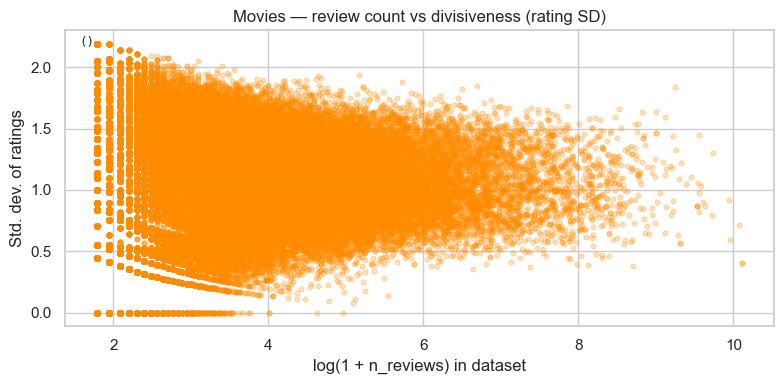

In [5]:
m2 = movies_f_std[movies_f_std["n_reviews"] >= MIN_MOVIE_REVIEWS]
x = m2["n_reviews"]
y = m2["std_rating"]

rep = correlation_report(x, y, "Movie: n_reviews vs rating_SD")
CORR_RESULTS.append(rep)

print("Movie review count vs rating SD (divisiveness) — correlation strength")
print(f"  n movies: {rep['n_points']:,}")
print(f"  Pearson r (raw count vs SD):     {rep['pearson_r_raw_n']:+.4f}  (p={rep['p_pearson_raw']:.2e})  [{rep['strength_raw_pearson']}]")
print(f"  Pearson r (log1p count vs SD):   {rep['pearson_r_log1p_n']:+.4f}  (p={rep['p_pearson_log1p']:.2e})  matches log-x axis; R²={rep['r_squared_log1p_pearson']:.4f}")
print(f"  Spearman rho (rank):             {rep['spearman_rho']:+.4f}  (p={rep['p_spearman']:.2e})  [{rep['strength_spearman']}]")
print(f"  Kendall tau:                     {rep['kendall_tau']:+.4f}  (p={rep['p_kendall']:.2e})")

plt.figure(figsize=(8, 4))
plt.scatter(np.log1p(x), y, alpha=0.25, s=12, color="darkorange")
plt.xlabel("log(1 + n_reviews) in dataset")
plt.ylabel("Std. dev. of ratings")
plt.title("Movies — review count vs divisiveness (rating SD)")
txt = ()
plt.gca().text(0.02, 0.98, txt, transform=plt.gca().transAxes, va="top", fontsize=9, family="monospace")
plt.tight_layout()
plt.show()


**How to read:** Higher SD means **more spread** across 1–5 stars (more disagreement). Near-zero SD means almost everyone gave the same star value.

**Interpretation.** Link **Spearman ρ** to whether disagreement grows or shrinks with exposure in this dataset. **Positive** ρ means movies with **more** reviews tend to have **higher** rating SD (**more divisive**—wider spread across 1–5★). **Negative** ρ means heavy-volume titles show **more consensus** (lower SD). **Near-zero** ρ implies divisiveness is **not** systematically tied to how often the movie appears in this dataset. Remember SD also depends on **how many stars actually vary** (two ratings both at 5★ have SD 0); interpret alongside **n** and the scatter cloud shape.

## 5. User activity vs average score (“harshness”)

**Question:** Is there a correlation between the number of reviews a user gives and how harshly they score films?

We operationalize **harshness** as **lower mean_rating** for that user (on the 1–5 scale), among users with at least `MIN_USER_REVIEWS` ratings so the mean is stable.

User review count vs mean rating (harshness proxy) — correlation strength
  n users: 311,221
  Pearson r (raw count vs mean):     -0.0234  (p=5.17e-39)  [negligible]
  Pearson r (log1p count vs mean):   -0.0207  (p=7.79e-31)  matches log-x axis; R²=0.0004
  Spearman rho (rank):             -0.0574  (p=2.82e-225)  [negligible]
  Kendall tau:                     -0.0408  (p=1.42e-218)


/var/folders/qq/w0x7mqq17y3_vgq8xckwfb980000gp/T/ipykernel_89951/3863865306.py:22: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


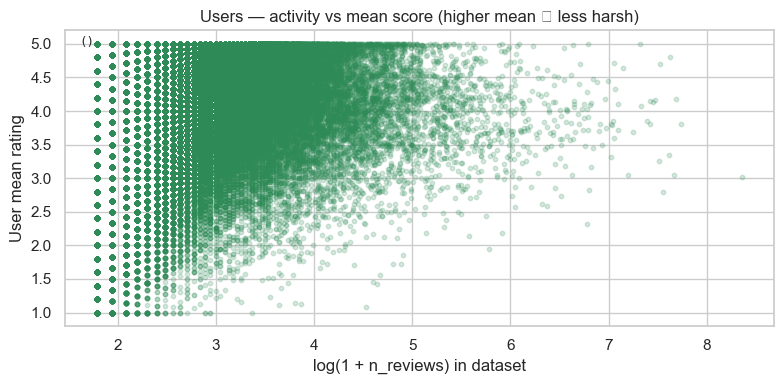

In [6]:
x = users_f["n_reviews"]
y = users_f["mean_rating"]

rep = correlation_report(x, y, "User: n_reviews vs mean_rating")
CORR_RESULTS.append(rep)

print("User review count vs mean rating (harshness proxy) — correlation strength")
print(f"  n users: {rep['n_points']:,}")
print(f"  Pearson r (raw count vs mean):     {rep['pearson_r_raw_n']:+.4f}  (p={rep['p_pearson_raw']:.2e})  [{rep['strength_raw_pearson']}]")
print(f"  Pearson r (log1p count vs mean):   {rep['pearson_r_log1p_n']:+.4f}  (p={rep['p_pearson_log1p']:.2e})  matches log-x axis; R²={rep['r_squared_log1p_pearson']:.4f}")
print(f"  Spearman rho (rank):             {rep['spearman_rho']:+.4f}  (p={rep['p_spearman']:.2e})  [{rep['strength_spearman']}]")
print(f"  Kendall tau:                     {rep['kendall_tau']:+.4f}  (p={rep['p_kendall']:.2e})")

plt.figure(figsize=(8, 4))
plt.scatter(np.log1p(x), y, alpha=0.2, s=10, color="seagreen")
plt.xlabel("log(1 + n_reviews) in dataset")
plt.ylabel("User mean rating")
plt.title("Users — activity vs mean score (higher mean ⇒ less harsh)")
txt = ()

plt.gca().text(0.02, 0.98, txt, transform=plt.gca().transAxes, va="top", fontsize=9, family="monospace")
plt.tight_layout()
plt.show()


### Note — correlation coefficients for each metric

Sections **3–5** print **Pearson *r*** (raw and log1p count where relevant), **Spearman ρ**, **Kendall τ**, and *p*-values for each scatter analysis. Section **6** adds **Pearson *r*** between star rating and the heavy-user indicator—that equals the **point-biserial** correlation for a 0/1 predictor.

A **single consolidated table** of all correlation coefficients appears **after section 6** (run sections **2→6** in order, then run that cell). **Pearson (log1p *n*)** matches the log-scaled *x*-axis on the scatter plots. **R²** is the squared Pearson *r* on log count. **Spearman** / **Kendall** summarize monotonic (rank) association.

In [7]:
# Consolidated coefficient table: run the cell under "## Correlation coefficients — all analyzed metrics" after sections 2–6.
pass

**How to read:** If correlation is **negative**, users who write **more** reviews in this dataset tend to give **lower** averages (appear harsher). Positive correlation ⇒ heavier reviewers rate higher on average. Self-selection and profile heterogeneity (genre tastes, early vs late adopters) can drive patterns.

**Interpretation.** Connect **Spearman ρ** to how **activity** relates to **mean strictness** (lower mean ⇒ harsher, on 1–5). A **negative** ρ means users with **more** reviews in the dataset give **lower** average scores—often read as more **critical** or **selective** heavy reviewers, or a **cohort effect** (long-tenure users vs casual one-offs). A **positive** ρ means busier raters are **less** harsh on average. **Near-zero** ρ says average score does not systematically move with how many reviews a user has in the file, so “harshness” and volume look **independent** in this dataset. This is still **not** proof of user “type”—self-selection, item mix, and time period all confound the link.

## 6. Heavy users: review behaviour

**Question:** Can we examine heavy users for certain review behaviour?

We label **heavy** users as those at or above the **90th percentile** of `n_reviews` among users with at least `MIN_USER_REVIEWS` reviews (change `HEAVY_QUANTILE` to explore). We compare **mean rating**, **SD of ratings**, and the **share of low (1–2★) vs high (4–5★)** reviews to **non-heavy** users.

In [8]:
HEAVY_QUANTILE = 0.90

thresh = users_f["n_reviews"].quantile(HEAVY_QUANTILE)
heavy_ids = set(users_f.loc[users_f["n_reviews"] >= thresh, "user_id"])
df_h = df["user_id"].isin(heavy_ids)

print(f"Heavy-user threshold: n_reviews ≥ {int(thresh)} (quantile {HEAVY_QUANTILE:.2f})")
print(f"Heavy users (in dataset): {len(heavy_ids):,}")

low = df["rating"] <= 2
high = df["rating"] >= 4

behaviour = pd.DataFrame(
    {
        "group": ["heavy", "non-heavy"],
        "share_of_all_reviews": [df_h.mean(), 1 - df_h.mean()],
        "mean_rating": [df.loc[df_h, "rating"].mean(), df.loc[~df_h, "rating"].mean()],
        "share_low_1_2": [low[df_h].mean(), low[~df_h].mean()],
        "share_high_4_5": [high[df_h].mean(), high[~df_h].mean()],
    }
)
display(behaviour)

# Within-user SD for users with enough rows
uheavy = user_stats[user_stats["user_id"].isin(heavy_ids) & (user_stats["n_reviews"] >= MIN_USER_REVIEWS)]
unon = user_stats[~user_stats["user_id"].isin(heavy_ids) & (user_stats["n_reviews"] >= MIN_USER_REVIEWS)]

print("Within-user rating SD (users with n≥MIN_USER_REVIEWS):")
print(f"  Heavy:    mean SD={uheavy['std_rating'].mean():.4f}, n_users={len(uheavy):,}")
print(f"  Non-heavy: mean SD={unon['std_rating'].mean():.4f}, n_users={len(unon):,}")

if len(uheavy) and len(unon):
    u = stats.mannwhitneyu(uheavy["std_rating"].dropna(), unon["std_rating"].dropna(), alternative="two-sided")
    print(f"  Mann–Whitney U (heavy vs non-heavy user SD): p={u.pvalue:.2e}")

# Correlation coefficients for heavy-user analysis (Pearson r = point-biserial for 0/1 heavy indicator)
HEAVY_CORR_LABEL = "Rating vs heavy_user_indicator (point-biserial)"
CORR_RESULTS[:] = [r for r in CORR_RESULTS if r.get("relationship") != HEAVY_CORR_LABEL]
rep_heavy = dichotomous_correlation_report(
    df_h.astype(float).to_numpy(),
    df["rating"].to_numpy(),
    HEAVY_CORR_LABEL,
)
CORR_RESULTS.append(rep_heavy)
print("\nCorrelation coefficients — star rating vs heavy-user indicator:")
print(f"  Pearson r (point-biserial): {rep_heavy['pearson_r_raw_n']:+.4f}  (p={rep_heavy['p_pearson_raw']:.2e})  [{rep_heavy['strength_raw_pearson']}]")
print(f"  Spearman rho:               {rep_heavy['spearman_rho']:+.4f}  (p={rep_heavy['p_spearman']:.2e})  [{rep_heavy['strength_spearman']}]")
print(f"  Kendall tau:                {rep_heavy['kendall_tau']:+.4f}  (p={rep_heavy['p_kendall']:.2e})")

Heavy-user threshold: n_reviews ≥ 19 (quantile 0.90)
Heavy users (in dataset): 32,905


,group,share_of_all_reviews,mean_rating,share_low_1_2,share_high_4_5
0,heavy,0.164255,4.155325,0.110123,0.768691
1,non-heavy,0.835745,4.248279,0.120325,0.803038


Within-user rating SD (users with n≥MIN_USER_REVIEWS):
  Heavy:    mean SD=0.8600, n_users=32,905
  Non-heavy: mean SD=0.7965, n_users=278,316
  Mann–Whitney U (heavy vs non-heavy user SD): p=2.29e-132

Correlation coefficients — star rating vs heavy-user indicator:
  Pearson r (point-biserial): -0.0282  (p=0.00e+00)  [negligible]
  Spearman rho:               -0.0575  (p=0.00e+00)  [negligible]
  Kendall tau:                -0.0541  (p=0.00e+00)


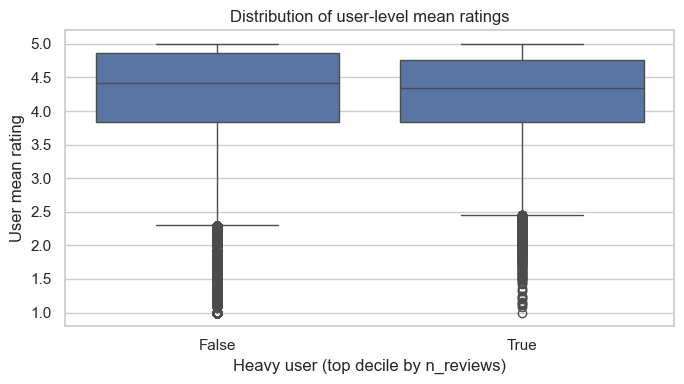

**What the box plot encodes** (each observation is one user’s **mean rating** among users with ≥`MIN_USER_REVIEWS` reviews): **median** = middle line inside the box; **box** = **Q1–Q3** (interquartile range, middle 50% of users); **whiskers** end at the furthest points within **1.5×IQR** from the box edges (matplotlib/seaborn default); points beyond that appear as **outlier dots** if any exist.

**Numeric summary** (definitions match the plot above):

,Group,n_users,min (data),Q1,median,Q3,max (data),IQR,whisker_low,whisker_high
0,Non-heavy,278316,1.0,3.8333,4.4167,4.8571,5.0,1.0238,2.2976,5.0
1,Heavy,32905,1.0,3.8400,4.3421,4.7662,5.0,0.9262,2.4506,5.0


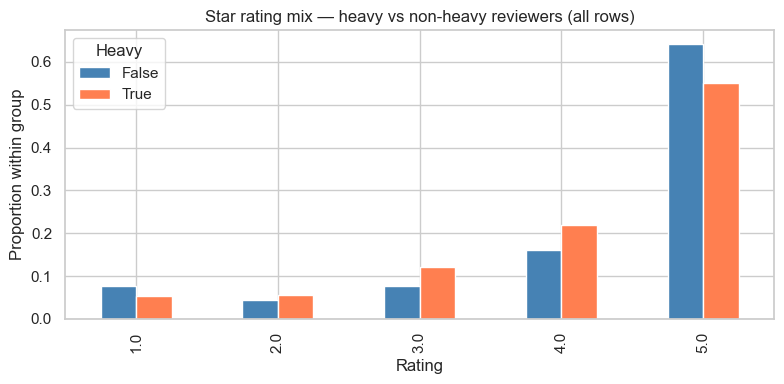

In [9]:
# Boxplots: distribution of per-user mean rating for heavy vs non-heavy (among filtered users)
users_f = users_f.copy()
users_f["heavy"] = users_f["user_id"].isin(heavy_ids)

plt.figure(figsize=(7, 4))
sns.boxplot(data=users_f, x="heavy", y="mean_rating", order=[False, True])
plt.xlabel("Heavy user (top decile by n_reviews)")
plt.ylabel("User mean rating")
plt.title("Distribution of user-level mean ratings")
plt.tight_layout()
plt.show()

display(
    Markdown(
        "**What the box plot encodes** (each observation is one user’s **mean rating** among users with "
        "≥`MIN_USER_REVIEWS` reviews): **median** = middle line inside the box; **box** = **Q1–Q3** (interquartile range, "
        "middle 50% of users); **whiskers** end at the furthest points within **1.5×IQR** from the box edges (matplotlib/seaborn "
        "default); points beyond that appear as **outlier dots** if any exist."
    )
)

rows = []
for heavy_val in [False, True]:
    r = users_f.loc[users_f["heavy"] == heavy_val, "mean_rating"]
    q1, med, q3 = r.quantile([0.25, 0.5, 0.75]).tolist()
    iqr = q3 - q1
    whisk_lo = max(float(r.min()), q1 - 1.5 * iqr)
    whisk_hi = min(float(r.max()), q3 + 1.5 * iqr)
    rows.append(
        {
            "Group": "Non-heavy" if heavy_val is False else "Heavy",
            "n_users": int(len(r)),
            "min (data)": float(r.min()),
            "Q1": q1,
            "median": med,
            "Q3": q3,
            "max (data)": float(r.max()),
            "IQR": iqr,
            "whisker_low": whisk_lo,
            "whisker_high": whisk_hi,
        }
    )
box_summary = pd.DataFrame(rows)
display(Markdown("**Numeric summary** (definitions match the plot above):"))
display(box_summary.round(4))

# Star-mix comparison (stacked proportions)
mix = (
    df.assign(heavy=df_h)
    .groupby(["heavy", "rating"])
    .size()
    .unstack(fill_value=0)
)
mix = mix.div(mix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
mix.T.plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.set_xlabel("Rating")
ax.set_ylabel("Proportion within group")
ax.set_title("Star rating mix — heavy vs non-heavy reviewers (all rows)")
ax.legend(title="Heavy")
plt.tight_layout()
plt.show()

## Correlation coefficients — all analyzed metrics

Each row is one **bivariate relationship**. **Pearson *r*** measures linear association (for review counts, both raw and log1p(*n*) where applicable). **Spearman ρ** and **Kendall τ** measure monotonic (rank) association. For the heavy-user row, **Pearson *r*** is the **point-biserial** correlation between a 0/1 indicator and star rating; log-scale columns are not applicable (shown as —).

In [10]:
METRIC_NAMES = {
    "Movie: n_reviews vs mean_rating": "Movie: review count ↔ mean rating",
    "Movie: n_reviews vs rating_SD": "Movie: review count ↔ rating SD (divisiveness)",
    "User: n_reviews vs mean_rating": "User: review count ↔ mean rating (harshness proxy)",
    "Rating vs heavy_user_indicator (point-biserial)": "Review-level: star rating ↔ heavy-user (0/1)",
}

full_tbl = pd.DataFrame(CORR_RESULTS).copy()
full_tbl.insert(0, "metric", full_tbl["relationship"].map(METRIC_NAMES).fillna(full_tbl["relationship"]))

out = full_tbl[
    [
        "metric",
        "n_points",
        "pearson_r_raw_n",
        "pearson_r_log1p_n",
        "r_squared_log1p_pearson",
        "spearman_rho",
        "kendall_tau",
        "p_pearson_raw",
        "p_pearson_log1p",
        "p_spearman",
        "p_kendall",
        "strength_raw_pearson",
        "strength_spearman",
    ]
].rename(
    columns={
        "n_points": "n",
        "pearson_r_raw_n": "Pearson r (raw n or point-biserial)",
        "pearson_r_log1p_n": "Pearson r (log1p n)",
        "r_squared_log1p_pearson": "R² (log Pearson)",
        "spearman_rho": "Spearman ρ",
        "kendall_tau": "Kendall τ",
        "p_pearson_raw": "p (Pearson raw / point-biserial)",
        "p_pearson_log1p": "p (Pearson log1p)",
        "p_spearman": "p (Spearman)",
        "p_kendall": "p (Kendall)",
        "strength_raw_pearson": "|r| strength (Pearson raw)",
        "strength_spearman": "|ρ| strength",
    }
)

_num = [c for c in out.columns if c not in ("metric", "|r| strength (Pearson raw)", "|ρ| strength")]
out[_num] = out[_num].apply(pd.to_numeric, errors="coerce").round(4)
out["n"] = out["n"].astype("Int64")

print("Correlation coefficients for each analyzed metric (Pearson r, Spearman ρ, Kendall τ):\n")
display(out)

Correlation coefficients for each analyzed metric (Pearson r, Spearman ρ, Kendall τ):



,metric,n,Pearson r (raw n or point-biserial),Pearson r (log1p n),R² (log Pearson),Spearman ρ,Kendall τ,p (Pearson raw / point-biserial),p (Pearson log1p),p (Spearman),p (Kendall),|r| strength (Pearson raw),|ρ| strength
0,Movie: review count ↔ mean rating,89590,0.0403,0.0981,0.0096,0.0672,0.0471,0.0000,0.0000,0.0,0.0,negligible,negligible
1,Movie: review count ↔ rating SD (divisiveness),89590,-0.0124,-0.0034,0.0000,-0.0310,-0.0269,0.0002,0.3049,0.0,0.0,negligible,negligible
2,User: review count ↔ mean rating (harshness pr...,311221,-0.0234,-0.0207,0.0004,-0.0574,-0.0408,0.0000,0.0000,0.0,0.0,negligible,negligible
3,Review-level: star rating ↔ heavy-user (0/1),8765568,-0.0282,NaN,NaN,-0.0575,-0.0541,0.0000,NaN,0.0,0.0,negligible,negligible


## 7. Short synthesis

- **Correlation coefficients:** Use the consolidated table above for **Pearson *r*** (raw or log1p count where applicable), **Spearman ρ**, **Kendall τ**, and *p*-values for each analysis—including **point-biserial *r*** for rating vs heavy-user status.
- **Movie count vs mean / SD:** Summarize the signs of the correlations you obtained and whether *p*-values suggest statistical significance **in this dataset** (this McAuley extract).
- **User count vs mean:** A trend links **volume** to **average strictness** within this Amazon Movies & TV extract; causal claims need richer modeling.
- **Heavy users:** Compare boxplot overlap and star-mix bars—large overlaps imply **similar** behaviour despite activity differences; systematic shifts support **different** behaviour among heavy reviewers.

**Next steps (optional):** stratify by `year` or genre if you merge metadata; use **bootstrap** confidence intervals for correlations; adjust for **minimum reviews** sensitivity analysis.


## 8. Conclusion — analysis by research check

Use this section after you have **run all cells** and recorded **your** correlations, *p*-values, plots, and tables. Fill in bracketed prompts with values from your outputs; the bullets summarize how each **check** answers the corresponding question using this notebook’s definitions.

### Check 1 — Movie review count vs mean rating

**Question:** Is popularity (review volume) associated with average star rating?

**Concluding analysis:** Compare **Spearman ρ** and **Pearson *r* on log1p(*n*)** (aligned with the log-scaled scatter) to judge direction and strength. If ρ is near zero and non-significant, conclude that **mean rating is essentially unrelated to how often the movie is reviewed** in this extract, once sparse titles are filtered out. If ρ is positive (negative), conclude that **more-reviewed movies tend toward higher (lower) average scores**—but stress **association, not causation** (genre, quality, and era confound visibility). Note that **Pearson on raw *n*** can look weaker than the plot because counts are skewed and the chart uses **log *n***.

### Check 2 — Movie review count vs divisiveness (rating SD)

**Question:** Are heavily reviewed movies more or less “divisive” (spread across 1–5★)?

**Concluding analysis:** Interpret **Spearman ρ** between review count and **within-movie rating SD**. A **positive** ρ supports **more disagreement** among popular titles; **negative** ρ supports **more consensus**. Near-zero ρ ⇒ **divisiveness does not systematically track popularity** here. Tie your wording to whether *p* passes your chosen significance bar and whether the **log-*x*** scatter shows any visible gradient versus wide overlap.

### Check 3 — User review count vs mean rating (“harshness”)

**Question:** Do users who write more reviews rate films lower on average?

**Concluding analysis:** Focus on the **sign** of ρ / Pearson(log): **negative** ⇒ users with **more reviews in the file** tend to give **lower** mean scores (read as “stricter” or more critical **on average**); **positive** ⇒ the opposite; **near zero** ⇒ **volume and harshness look unrelated** among users meeting `MIN_USER_REVIEWS`. Acknowledge confounds (different tastes, items reviewed, time period).

### Check 4 — Heavy users vs others

**Question:** Do heavy reviewers show distinct behaviour?

**Concluding analysis:** Integrate (i) the **group summary table** (means, low/high star shares), (ii) **within-user SD** comparison and Mann–Whitney *p* if printed, (iii) **box-plot summary statistics**, (iv) **star-mix bars**, and (v) **point-biserial *r*** between rating and the heavy-user indicator. Conclude whether heavy users are **materially different** or **largely overlapping** with non-heavy users on mean rating and spread. If overlaps are large and effect sizes small, say behaviour is **similar** despite higher activity; if means or mixes diverge consistently, say heavy users show **detectably different** rating patterns **in this dataset**.

### Closing remark

Together, these checks describe **structure in the McAuley Movies & TV reviews file**, not universal truths about Amazon or movies generally. Prefer language that matches **your printed coefficients and visual evidence**, and note limitations (**single domain extract**, **minimum-review filters**, **correlation ≠ causation**).